In [ ]:
# importing the basic libraries
import numpy as np # to handle numeric values
import pandas as pd # to handle data related task
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries loaded successfully!")


All libraries loaded successfully!


We are using the Housing Price Dataset from Kaggle.datasets 

In [ ]:
df = pd.read_csv(r"C:\Users\Greesha Vaishnavi\Desktop\Housing_Prices\Housing.csv") # fetching file folder and reading the file

"Shape:", 
df.shape
df.head()  
#here what we done is we are reaching into the package and pulling out clean excel like table and saving it in the dataframe(pandas) so that we can easily access for our operations

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
X = df.drop(columns = ['price']) # basically the split is like X=> which has all the features or one feature if it has multiple features it will be a feature matrix(expect target variable)
y = df['price'] # y is our target variable

next step is to split our data into training and testing, which is again being done by sci-kit learn library,
why? because we wnat to train our model on some data and check against some data if it is working perfectly or not
the usual split is 80% training and 20% testing, we can change as our wish, the output may also change, the accuracy

In [ ]:
df.info()   # information of the collected column data  and their data types if they are str type we have to convert to int data type cause prediction in regression takes in numeric form

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()
# checking std stats values in the given datasets 

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.isnull().sum() #counts the total number of missing (null) values in each column pandas DataFrame

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
df.duplicated().sum() # checking all the duplicate values in each colunm pandas DataFrame

np.int64(0)

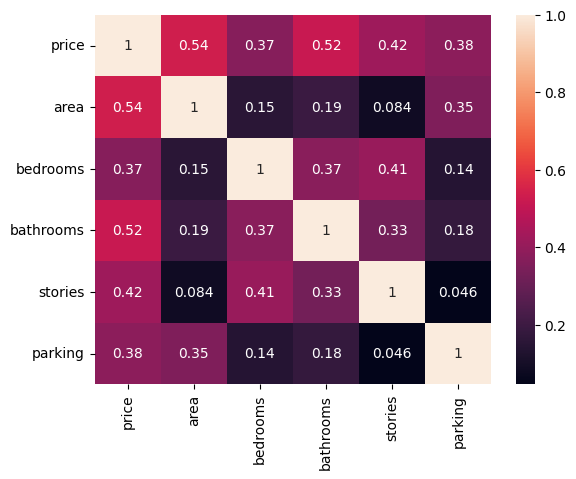

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='price'>

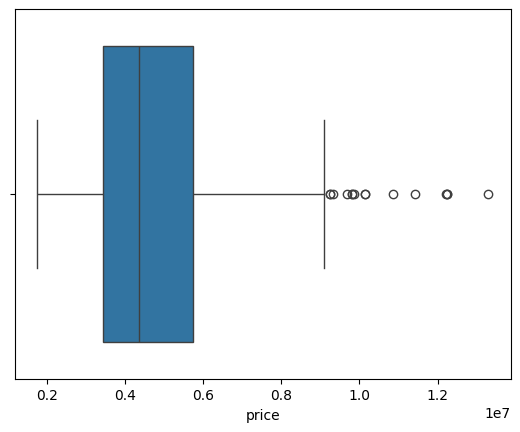

In [ ]:
sns.boxplot(x=df["price"])

This is a horizontal boxplot visualizing the distribution of the price variable. 
It highlights the central tendency, spread, and extreme values (outliers) of your dataset.
The Scale (1e7): The bottom axis uses scientific notation. Multiply the numbers on the axis (0.2 to 1.2) by (10,000,000). For example, (1.0) represents a price of (10,000,000).
The Main Blue Box: This represents the Interquartile Range (IQR), which contains the middle 50% of your data.
Left Edge: The 25th percentile (Q1). About 25% of data falls below this price (around (3,000,000)).
Right Edge: The 75th percentile (Q3). About 75% of data falls below this price (around (6,000,000)).
The Central Line: The vertical line inside the blue box is the Median (50th percentile). It splits your data exactly in half (around (4,500,000)).
The Whiskers: The lines extending out from the box show the rest of the distribution. They extend to (1.5 times text{IQR}) past the box to show the range of typical data.
The Circles (Outliers): Individual points beyond the right whisker (starting around (9,000,000) up to over (12,000,000)) represent high-price outliers. 
These are unusually expensive data points relative to the rest of the dataset.
DataSkewness: The data is right-skewed (positively skewed) because the right whisker is longer and all individual outlier points stretch out to the right side.Price 
Concentration: Most of your data is concentrated at lower price points (between (3,000,000) and (6,500,000)), with a tail of premium, high-value exceptions

In [ ]:
columns = [                                       
    'mainroad',
    'guestroom',               # endcoding process : the process of converting information or data from one format into another
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea']
for col in columns:
    df[col]=df[col].map({'yes':1 ,'no':1})


changing all str data type colums to int data type by using binary values 0 and 1 because many many ml models cant understand the raw data . yes as 1 and no as 0   

In [ ]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)       
 

One-Hot encoding : a data preprocessing technique that converts categorical text or labels into binary vectors (0s and 1s) . 
Like in furnishingstatus we have 3 categorised data i.e., furnitured,unfurnitured and semifurnitured data these will be form of 1s and 0s.
afrer drop_first=True if a row represents a "furnished" property, both remaining columns become 0. The model automatically deduces the missing category from this baseline. 
Like in 1st row its furnished and it is 1 remaining 2 rows will be 0 

In [ ]:
X = df.drop(columns = ['price'])
y = df['price']

Basicailly we are split our data in two variables X and y . X=> which contains all the features or one feature, if it is multiple features then it will be a feature matrix(except tgt variable)
y=> is the target variable

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

next step is to split our data into training and testing, which is again being done by sci-kit learn library,
why? because we wantt to train our model on some data and check against some data if it is working perfectly or not.
Then usual split is 80% training and 20% testing, we can change as our wish, the output may also change and the accuracy

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)           #since y is the target variable price . we well split y variable in train and test 

(436, 13)
(109, 13)
(436,)
(109,)


next step is to fit the model, model is again available in skleanr which is also called scikit learn

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


we have successfully trained the model, now we have to predict it and get the accuracy.

we have trained the model only on the training data, we are now going to predict it on the test data, the model hasn't been feeded the test data, it is a new date for it

we have the prediction module in sklearn and to measure the accuracy we need some metrics which are again available in sklearn itself, we can use:

mean square error, r2 score, rmse etc, based on the project requirement

In [ ]:
y_pred = model.predict(X_test)

#prediction done

In [ ]:
#metrics to measure accuracy
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [ ]:
print(mse)                    # checking accuracy in target variable price 
print(r2)

2229169358205.0586
0.5589794483892095


In [ ]:
# Print the feature names alongside their learned weights

for feature, weight in zip(X.columns, model.coef_):
    print(f"{feature}: {weight}")

area: 300.8286350740691
bedrooms: 144537.7138660089
bathrooms: 1154900.5149259313
stories: 464070.1816630053
mainroad: -2.3283064365386963e-10
guestroom: 3.4924596548080444e-10
basement: 0.0
hotwaterheating: 0.0
airconditioning: 0.0
parking: 294519.57224558096
prefarea: 0.0
furnishingstatus_semi-furnished: -280890.18388614396
furnishingstatus_unfurnished: -686630.2666045935
